In [30]:
import numpy as np
import pandas as pd
from pathlib import Path
from common.consts import long_to_short

def read_colvar_with_fields(path: Path) -> pd.DataFrame:
    with path.open() as f:
        header = next(line for line in f if line.startswith("#!"))
    parts = header.strip().split()

    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

wt = "chignolin"
rmsd_threshold = 0.1
wt_path = Path(f"../data/{wt}/output/run_000/COLVAR_000")
df_wt = read_colvar_with_fields(wt_path)

# select only dXX descriptors
descriptors = [c for c in df_wt.columns if c.startswith("d")]

df_wt_filt = df_wt[df_wt["rmsd"] < rmsd_threshold]
var_wt = df_wt_filt[descriptors].var(ddof=1)
p_wt = var_wt / var_wt.sum()
entropy_wt = -(p_wt * np.log(p_wt)).sum()


rows, index = [], []
proteins = list(long_to_short.keys())
# proteins.remove("YYDPETGQWY")

for protein in proteins:
    path = Path(f"../data/{protein}/output/run_000/COLVAR_000")
    df = read_colvar_with_fields(path)

    # filter mutant
    df_filt = df[df["rmsd"] < rmsd_threshold]
    var_mut = df_filt[descriptors].var(ddof=1)

    delta = var_wt - var_mut
    abs_delta = delta.abs()
    rel_delta = delta / var_wt.replace(0, pd.NA)

    p_mut = var_mut / var_mut.sum()
    entropy_mut = -(p_mut * np.log(p_mut)).sum()

    out = delta.to_dict()
    out["sum_delta"] = delta.sum()
    out["sum_abs_delta"] = abs_delta.sum()
    out["mean_abs_delta"] = abs_delta.mean()
    out["mean_rel_delta"] = rel_delta.mean(skipna=True)
    out["var_corr"] = var_wt.corr(var_mut)
    out["delta_total_var"] = var_wt.sum() - var_mut.sum()
    out["delta_entropy"] = entropy_wt - entropy_mut

    rows.append(out)
    index.append(protein)

result = pd.DataFrame(rows, index=index).sort_values("sum_delta", ascending=False)
result.index = [long_to_short.get(name, name) for name in result.index]
print(result)


          d03       d04       d05       d06       d07       d08       d09  \
P3R -0.000142 -0.000157  0.000154  0.000498 -0.000008  0.000095  0.000116   
Y0R  0.000022  0.000141  0.000120  0.000577  0.000030 -0.000011  0.000017   
P3C -0.000159 -0.000400 -0.000413  0.000582  0.000034  0.000017  0.000226   
T7Y -0.000024 -0.000313 -0.000261  0.000662  0.000007  0.000068  0.000291   
D2M -0.000117 -0.000185 -0.000124  0.000283 -0.000059  0.000051  0.000240   
WT   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
D2C -0.000059 -0.000258 -0.000101  0.000495 -0.000050  0.000078  0.000189   
P3M -0.000163 -0.000176 -0.000120  0.000503  0.000063  0.000066 -0.000056   
D2E -0.000058 -0.000461 -0.000464  0.000462 -0.000070 -0.000123 -0.000138   
D2A -0.000112 -0.000429 -0.000380  0.000442 -0.000111 -0.000222 -0.000320   
Y0E -0.000089 -0.000741 -0.000865  0.000693 -0.000003  0.000015  0.000216   
T7D -0.000046 -0.000229 -0.000134  0.000909  0.000146  0.000225  0.000175   

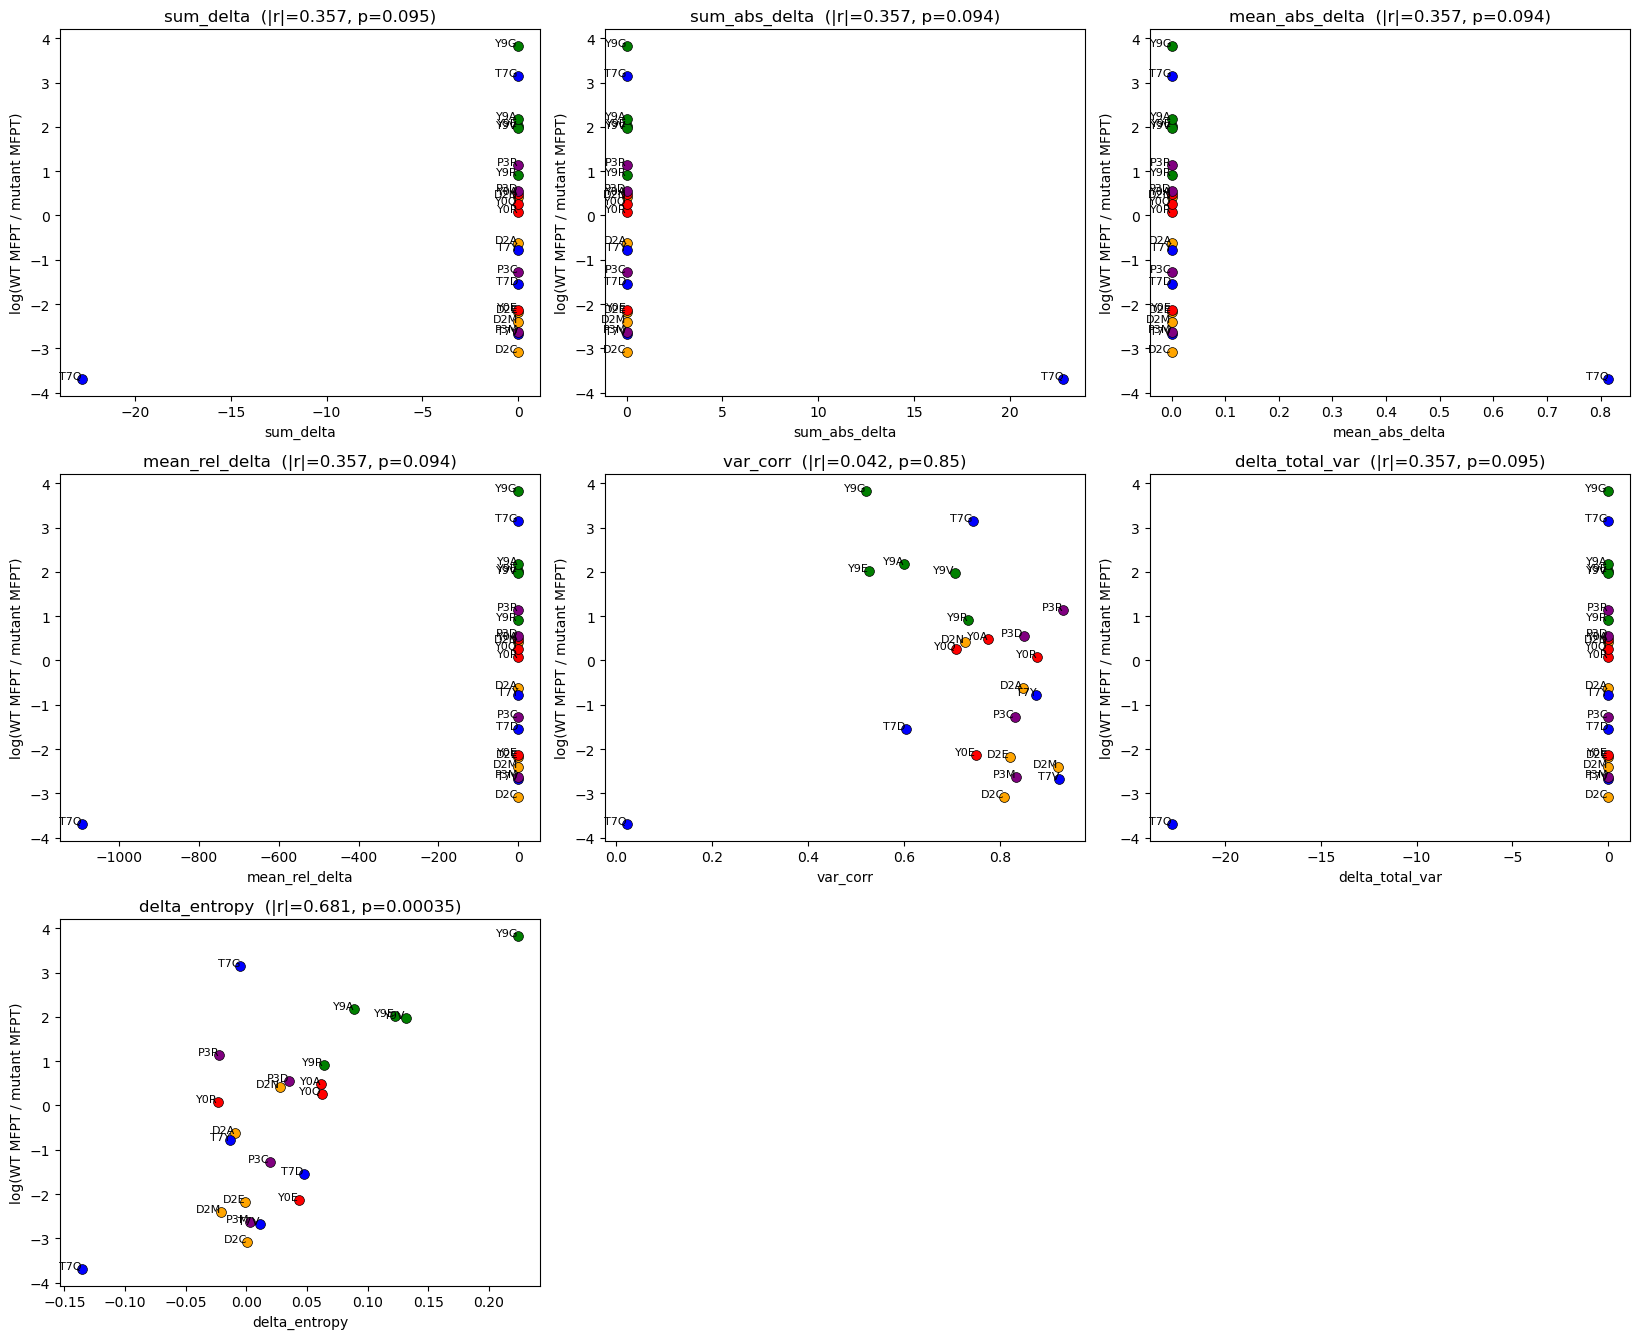

In [ ]:
from scipy.stats import pearsonr
from common.utils import collect_df
from common.consts import res_colors
import numpy as np
import pickle
import matplotlib.pyplot as plt
import re

parsed = result.drop('Y9Q').drop('D2R').drop('T7R').drop('T7Q')

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)
    
thresholds = np.array(list(all_mfpt['chignolin'].keys()))
df = collect_df(True, all_mfpt, thresholds[1])

mfpt = df['mfpt']
y = np.log(mfpt['WT'] / mfpt.drop(labels=["WT"], errors="ignore"))

stats_cols = [
    "sum_delta", "sum_abs_delta", "mean_abs_delta",
    "mean_rel_delta", "var_corr", "delta_total_var", "delta_entropy",
]
stats_cols = [s for s in stats_cols if s in parsed.columns]

common = y.index.intersection(parsed.index)
y = y.loc[common]

def get_res_idx(name: str) -> int:
    m = re.search(r"(\d+)", name)
    return int(m.group(1))

n = len(stats_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.5*nrows), squeeze=False)

for ax, s in zip(axes.flat, stats_cols):
    x = parsed.loc[common, s]
    mask = ~(x.isna() | y.isna())
    xr, yr = x[mask].to_numpy(), y[mask].to_numpy()

    if len(xr) >= 2 and np.std(xr) > 0 and np.std(yr) > 0:
        r, p = pearsonr(xr, yr)
        title = f"{s}  (|r|={abs(r):.3f}, p={p:.2g})"
    else:
        title = f"{s}  (|r|=nan, p=nan)"

    for name in common:
        xi, yi = x.loc[name], y.loc[name]
        idx = get_res_idx(name)
        color = res_colors.get(idx, "gray")
        ax.scatter(xi, yi, color=color, s=50, edgecolor="k", linewidth=0.5)
        ax.text(xi, yi, name, fontsize=8, ha="right")

    ax.set_xlabel(s)
    ax.set_ylabel("log(WT MFPT / mutant MFPT)")
    ax.set_title(title)

for ax in axes.flat[len(stats_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
